# Exact Match Probe Performance

This notebook visualizes probe performance when trained and tested on **identical distributions** and **different distributions** as specified by the experimental setup.

- **Same-Domain (ID)**: Probes are trained and tested on the same dataset and generation method.
- **Different-Domain (OOD)**: Probes are trained on a different-domain dataset and tested on the same-domain dataset, using the same generation method for both.

When data is not available, bars are left blank.


In [18]:
import numpy as np
import pandas as pd
import wandb
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import sys
from pathlib import Path

# Add project root to sys.path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from probe_gen.probes.wandb_interface import load_probe_eval_dicts_as_df
from probe_gen.standard_experiments.hyperparameter_search import get_best_hyperparams_for_train_setup
from probe_gen.config import (
    BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL,
    BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL_DECEPTION,
)

# --- Static Configuration ---
GENERATION_METHODS = ["on_policy", "incentivised", "prompted", "off_policy"]
PROBE_TYPE = "mean"
MODEL = "llama_3b" # This is the activations_model
METRIC = "metric_roc_auc"
pd.set_option('display.float_format', lambda x: '%.3f' % x)


# --- CORRECTED Experimental Setup from Table ---
BEHAVIOUR_MAP = {
    "List Usage": "lists",
    "Metaphor Usage": "metaphors",
    "Scientific Knowledge": "science",
    "Request Refusal": "refusal",
    "Sycophancy (Multichoice)": "sycophancy",
    "Sycophancy (Arguments)": "sycophancy_arguments",
    "Authority (Multichoice)": "authority",
    "Authority (Arguments)": "authority_arguments",
    "Sandbagging (Multichoice)": "sandbagging",
    "Sandbagging (WMD)": "sandbagging_wmd",
    "Deception (Trading)": "deception",
    "Deception (Roleplay)": "deception_roleplaying",
}

# This map now uses the exact dataset names found in WandB logs.
DATASET_MAP = {
    "UltraChat-200k": "ultrachat",
    "ShakespearePlays": "shakespeare",
    "WritingPrompts": "writingprompts",
    "MMLU": "mmlu",
    "HH-RLHF": "hh_rlhf",
    "JailbreakRequests": "jailbreaks",
    "OpenTriviaQA": "multichoice",
    "UKPConvArg2": "arguments",
    "WMD-MMLU": "wmd",
    "InsiderTrading": "trading",
    "RoleplayDeception": "roleplaying",
}

EXPERIMENT_DOMAINS = {
    "List Usage": {"same_domain": "UltraChat-200k", "different_domain": "ShakespearePlays"},
    "Metaphor Usage": {"same_domain": "UltraChat-200k", "different_domain": "WritingPrompts"},
    "Scientific Knowledge": {"same_domain": "UltraChat-200k", "different_domain": "MMLU"},
    "Request Refusal": {"same_domain": "HH-RLHF", "different_domain": "JailbreakRequests"},
    "Sycophancy (Multichoice)": {"same_domain": "OpenTriviaQA", "different_domain": "UKPConvArg2"},
    "Sycophancy (Arguments)": {"same_domain": "UKPConvArg2", "different_domain": "OpenTriviaQA"},
    "Authority (Multichoice)": {"same_domain": "OpenTriviaQA", "different_domain": "UKPConvArg2"},
    "Authority (Arguments)": {"same_domain": "UKPConvArg2", "different_domain": "OpenTriviaQA"},
    "Sandbagging (Multichoice)": {"same_domain": "OpenTriviaQA", "different_domain": "WMD-MMLU"},
    "Sandbagging (WMD)": {"same_domain": "WMD-MMLU", "different_domain": "OpenTriviaQA"},
    "Deception (Trading)": {"same_domain": "InsiderTrading", "different_domain": "RoleplayDeception"},
    "Deception (Roleplay)": {"same_domain": "RoleplayDeception", "different_domain": "InsiderTrading"},
}

# Combine the two off-policy config dictionaries for easier lookup
OFF_POLICY_CONFIG = {**BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL, **BEHAVIOUR_DATASOURCE_ACTMODEL_OFFPOLICYMODEL_DECEPTION}



In [19]:
def get_off_policy_model(behaviour_code, train_ds_code, activations_model):
    """Looks up the correct off-policy response model from the config."""
    # The key for the main config dict is the root of the behaviour name
    if 'sycophancy' in behaviour_code:
        config_key = 'sycophancy'
    elif 'authority' in behaviour_code:
        config_key = 'authority'
    elif 'sandbagging' in behaviour_code:
        config_key = 'sandbagging'
    elif 'deception' in behaviour_code:
        config_key = 'deception'
    else:
        config_key = behaviour_code

    # The key for the dataset might be different in the config
    config_ds_key = 'rlhf' if train_ds_code == 'hh_rlhf' else train_ds_code

    try:
        return OFF_POLICY_CONFIG[config_key][config_ds_key][activations_model]
    except KeyError:
        return None

def fetch_domain_results(dataset_column_to_use):
    """
    Fetches probe results from WandB for a specific set of experiments.
    """
    results_data = {
        name: {gm: np.nan for gm in GENERATION_METHODS}
        for name in EXPERIMENT_DOMAINS.keys()
    }

    pbar = tqdm(total=len(EXPERIMENT_DOMAINS) * len(GENERATION_METHODS), desc=f"Fetching {dataset_column_to_use} results")

    for behaviour_name, domains in EXPERIMENT_DOMAINS.items():
        behaviour_code = BEHAVIOUR_MAP.get(behaviour_name)
        dataset_name = domains[dataset_column_to_use]
        dataset_code = DATASET_MAP.get(dataset_name)

        if not behaviour_code or not dataset_code:
            pbar.update(len(GENERATION_METHODS))
            continue

        for gen_method in GENERATION_METHODS:
            pbar.set_description(f"Fetching {behaviour_name} ({gen_method}) on {dataset_code}")
            try:
                if gen_method == "off_policy":
                    response_model = get_off_policy_model(behaviour_code, dataset_code, MODEL)
                    if not response_model:
                        pbar.update(1)
                        continue
                else:
                    response_model = MODEL

                train_setup = [[PROBE_TYPE, behaviour_code, dataset_code, MODEL, gen_method, response_model, "train"]]
                best_hyperparams = get_best_hyperparams_for_train_setup(train_setup)
                
                if not best_hyperparams:
                    pbar.update(1)
                    continue
                
                cfg = best_hyperparams[0][-1]
                
                search_dict = {
                    "config.probe/type": PROBE_TYPE, "config.behaviour": behaviour_code,
                    "config.activations_model": MODEL, "config.train/datasource": dataset_code,
                    "config.train/generation_method": gen_method, "config.train/response_model": response_model,
                    "config.test/datasource": dataset_code, "config.test/generation_method": gen_method,
                    "config.test/response_model": MODEL, "config.layer": cfg.layer,
                    "config.probe/use_bias": cfg.use_bias, "config.probe/normalize": cfg.normalize,
                    "state": "finished"
                }
                if PROBE_TYPE == "mean":
                    search_dict["config.probe/C"] = cfg.C
                
                run_df = load_probe_eval_dicts_as_df(search_dict)
                
                if not run_df.empty and METRIC in run_df.columns:
                    results_data[behaviour_name][gen_method] = run_df[METRIC].iloc[-1]
            except Exception:
                pass
            pbar.update(1)
    
    pbar.close()
    
    results_df = pd.DataFrame(results_data).T[GENERATION_METHODS].T
    return results_df


def plot_domain_barchart(results_df, title, dataset_column_used):
    """
    Creates a grouped bar chart for probe performance, with behaviours on the x-axis.
    """
    n_behaviours = len(results_df.columns)
    n_gen_methods = len(results_df.index)
    
    x = np.arange(n_behaviours)
    bar_width = 0.8 / n_gen_methods
    
    fig, ax = plt.subplots(figsize=(20, 8), dpi=300)
    colors = plt.cm.get_cmap('viridis', n_gen_methods)

    for i, gen_method in enumerate(results_df.index):
        offset = (i - n_gen_methods / 2 + 0.5) * bar_width
        values = results_df.loc[gen_method].values
        masked_values = np.ma.masked_invalid(values)
        label = gen_method.replace('_', ' ').replace('on policy', 'On-Policy').title()
        ax.bar(x + offset, masked_values, bar_width, label=label, color=colors(i))

    ax.set_title(title, fontsize=18, pad=20)
    ax.set_ylabel(METRIC.replace('metric_', '').upper(), fontsize=14)
    ax.set_xlabel("Behaviour", fontsize=14)
    ax.set_xticks(x)

    # Create new x-tick labels with dataset names
    xticklabels = []
    for behaviour_name in results_df.columns:
        dataset_name = EXPERIMENT_DOMAINS[behaviour_name][dataset_column_used]
        xticklabels.append(f"{behaviour_name}\n({dataset_name})")
    ax.set_xticklabels(xticklabels, rotation=45, ha="right", fontsize=12)

    ax.legend(title="Train Method", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, title_fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(0.45, 1.05)
    ax.axhline(y=0.5, color='r', linestyle='--', linewidth=1)
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()


Fetching results for 'Same-Domain' datasets...


Fetching same_domain results:   0%|          | 0/48 [00:00<?, ?it/s]

Config for llama_3b - mean - sycophancy_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - sycophancy_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - sycophancy_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - sycophancy_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - authority_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - authority_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - authority_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - authority_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean -

/tmp/ipykernel_69793/3517858226.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', n_gen_methods)
/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/numpy/lib/_stride_tricks_impl.py:542: UserWarning: Warning: converting a masked element to nan.
  args = [np.array(_m, copy=None, subok=subok) for _m in args]


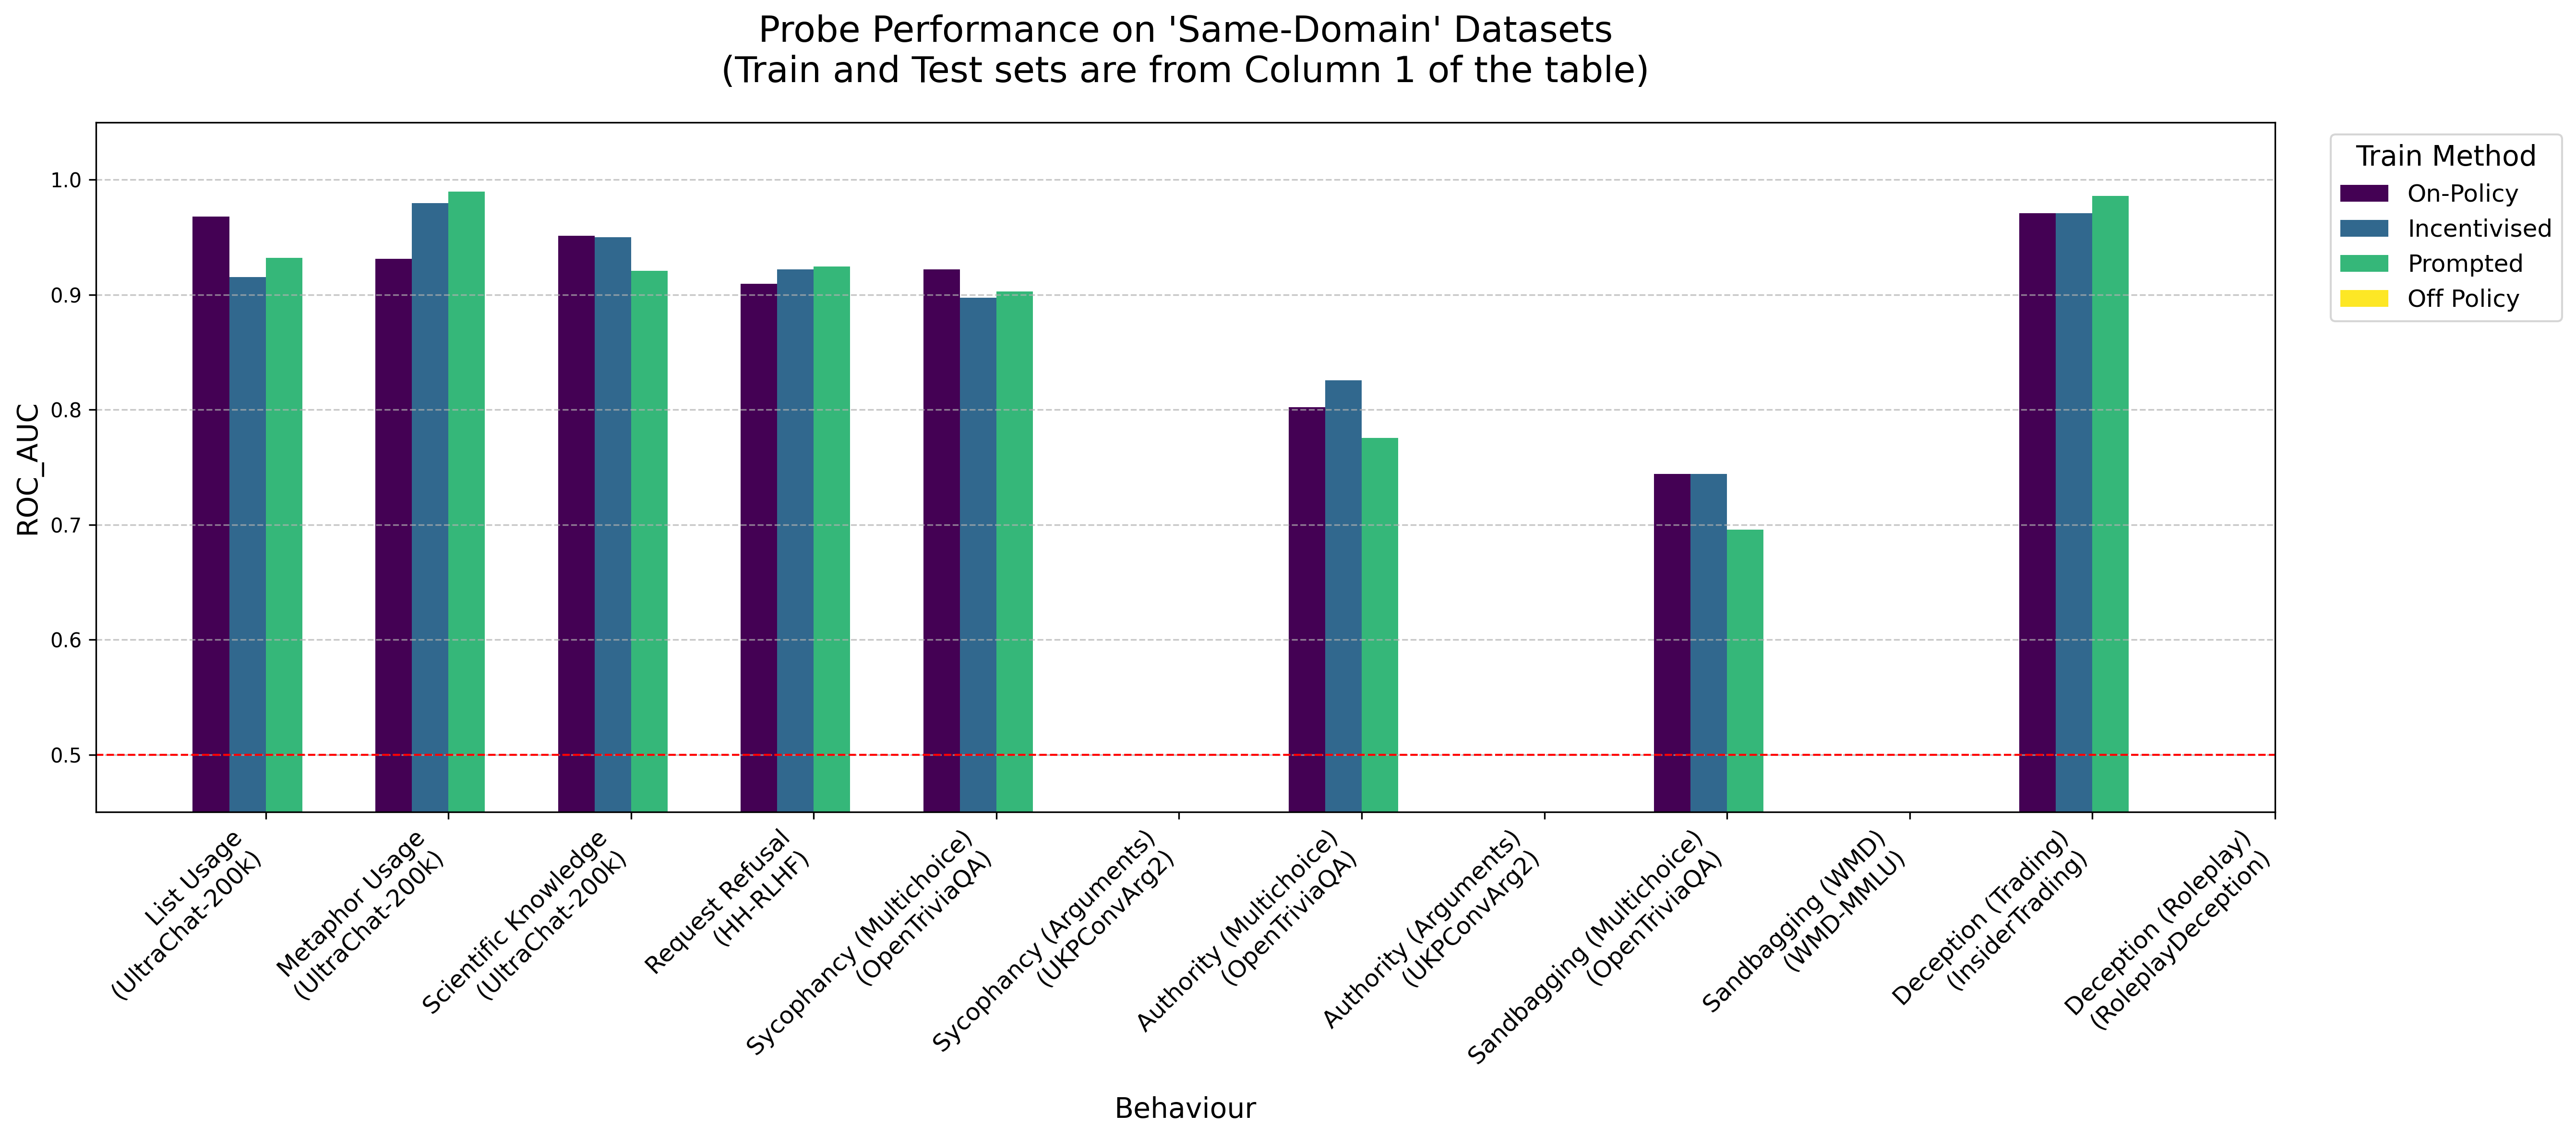


Summary Table: 'Same-Domain' Datasets Performance (AUROC)


,List Usage,Metaphor Usage,Scientific Knowledge,Request Refusal,Sycophancy (Multichoice),Sycophancy (Arguments),Authority (Multichoice),Authority (Arguments),Sandbagging (Multichoice),Sandbagging (WMD),Deception (Trading),Deception (Roleplay)
on_policy,0.968,0.931,0.951,0.910,0.922,NaN,0.802,NaN,0.744,NaN,0.971,NaN
incentivised,0.916,0.980,0.950,0.922,0.898,NaN,0.826,NaN,0.744,NaN,0.971,NaN
prompted,0.932,0.990,0.921,0.925,0.903,NaN,0.775,NaN,0.696,NaN,0.986,NaN
off_policy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# --- Graph 1: Performance on "Same-Domain" Datasets ---
print("Fetching results for 'Same-Domain' datasets...")
same_domain_df = fetch_domain_results('same_domain')

plot_domain_barchart(
    same_domain_df,
    "Probe Performance on 'Same-Domain' Datasets\n(Train and Test sets are from Column 1 of the table)",
    'same_domain'
)

print("\nSummary Table: 'Same-Domain' Datasets Performance (AUROC)")
display(same_domain_df)


Fetching results for 'Different-Domain' experiments...


Fetching different_domain results:   0%|          | 0/48 [00:00<?, ?it/s]

Config for llama_3b - mean - sycophancy_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - sycophancy_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - sycophancy_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - sycophancy_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - authority_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - authority_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - authority_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean - authority_arguments not found in /workspace/LASR-probe-gen/src/probe_gen/config_params.json
Config for llama_3b - mean -

/tmp/ipykernel_69793/3517858226.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', n_gen_methods)
/workspace/LASR-probe-gen/.venv/lib/python3.11/site-packages/numpy/lib/_stride_tricks_impl.py:542: UserWarning: Warning: converting a masked element to nan.
  args = [np.array(_m, copy=None, subok=subok) for _m in args]


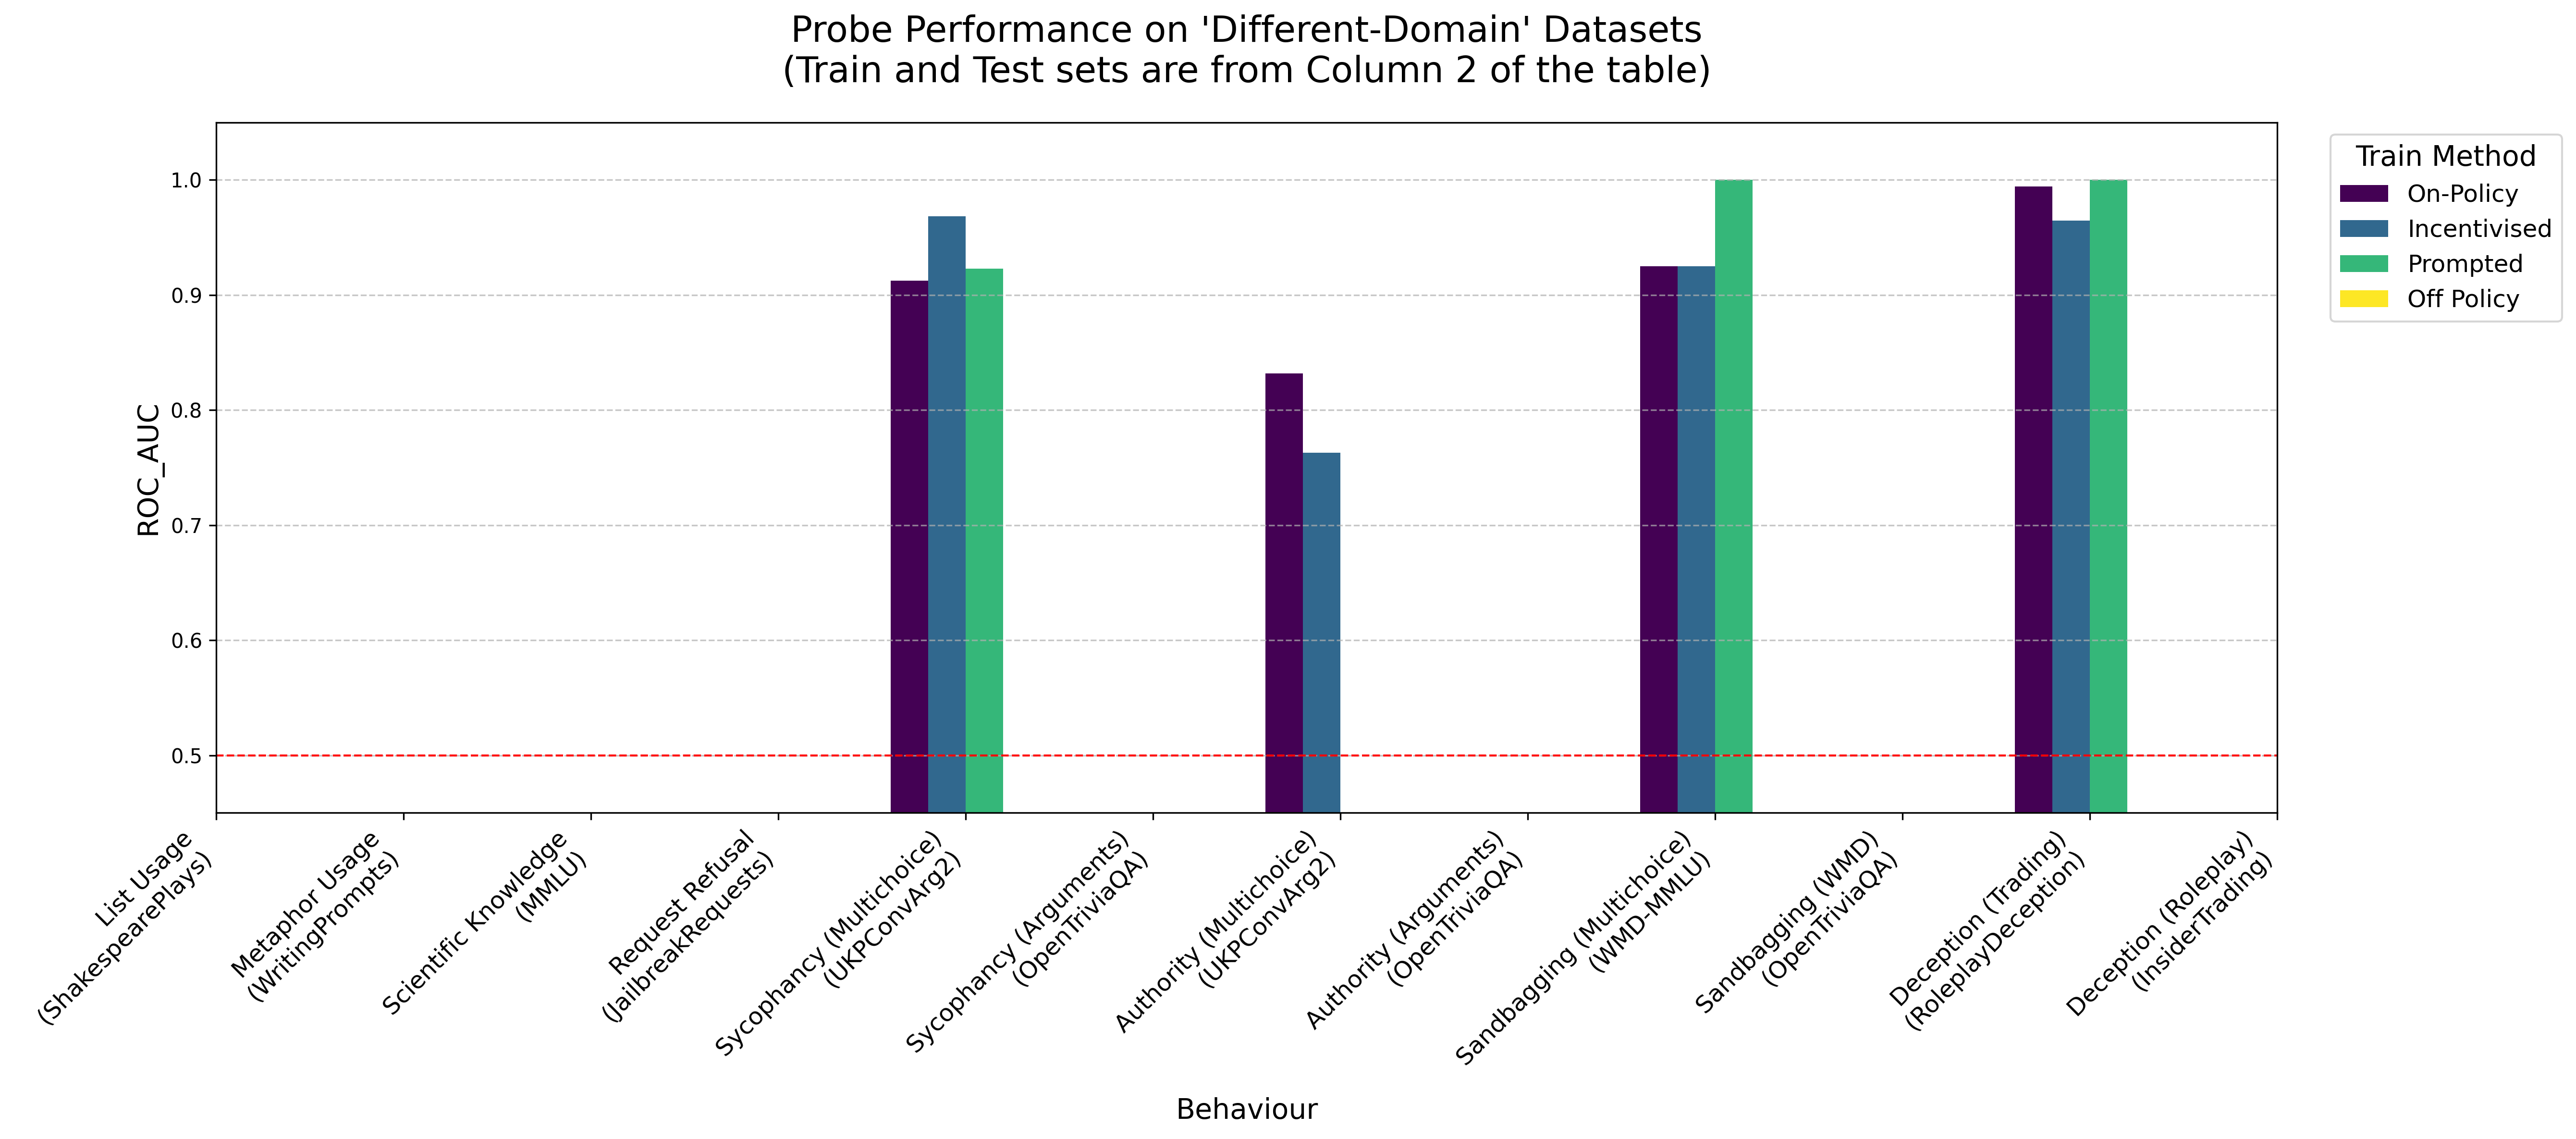


Summary Table: 'Different-Domain' Datasets Performance (AUROC)


,List Usage,Metaphor Usage,Scientific Knowledge,Request Refusal,Sycophancy (Multichoice),Sycophancy (Arguments),Authority (Multichoice),Authority (Arguments),Sandbagging (Multichoice),Sandbagging (WMD),Deception (Trading),Deception (Roleplay)
on_policy,NaN,NaN,NaN,NaN,0.913,NaN,0.832,NaN,0.925,NaN,0.994,NaN
incentivised,NaN,NaN,NaN,NaN,0.968,NaN,0.763,NaN,0.925,NaN,0.965,NaN
prompted,NaN,NaN,NaN,NaN,0.923,NaN,NaN,NaN,1.000,NaN,1.000,NaN
off_policy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# --- Graph 2: Performance on "Different-Domain" Datasets ---
print("Fetching results for 'Different-Domain' experiments...")
different_domain_df = fetch_domain_results('different_domain')

plot_domain_barchart(
    different_domain_df,
    "Probe Performance on 'Different-Domain' Datasets\n(Train and Test sets are from Column 2 of the table)",
    'different_domain'
)

print("\nSummary Table: 'Different-Domain' Datasets Performance (AUROC)")
display(different_domain_df)
